# **APE003: Grupo I**

### Teoría de la Distribución y Probabilidad

#### **Integrantes:**


*   Luis Armijos
*   Kiara Condoy
*   Javier Guarnizo
*   Hector Guerrero
*   Ricardo Ochoa
*   Emily Salas



### **Celda 1: Configuración**

In [1]:
# ==========================================
# 1. Configuración Inicial
# ==========================================
# Importamos las librerías clásicas para manejo de datos, estadística y gráficos
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools

# Configuramos el estilo de seaborn para que los gráficos se vean más limpios y profesionales
sns.set_theme(style="whitegrid")

### **Celda 2: Caso Discreto**

Caso: X = resultado del lanzamiento de un dado justo
Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999



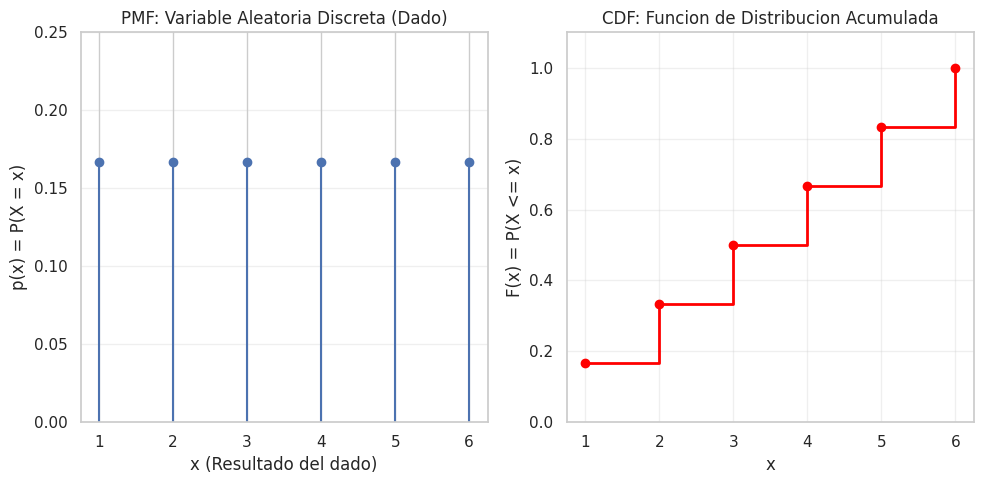


Probabilidades especificas:
P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


In [25]:
# Caso: X = resultado del lanzamiento de un dado justo.
# 2. Defina la variable aleatoria y su PMF:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Caso: X = resultado del lanzamiento de un dado justo")
print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))
print("")
# 3. Visualice la PMF:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# 4. Calcule probabilidades especificas:
print("\nProbabilidades especificas:")
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")

### **Celda 3: Caso Continuo**

--- Resultados del Caso Continuo (Servidor) ---


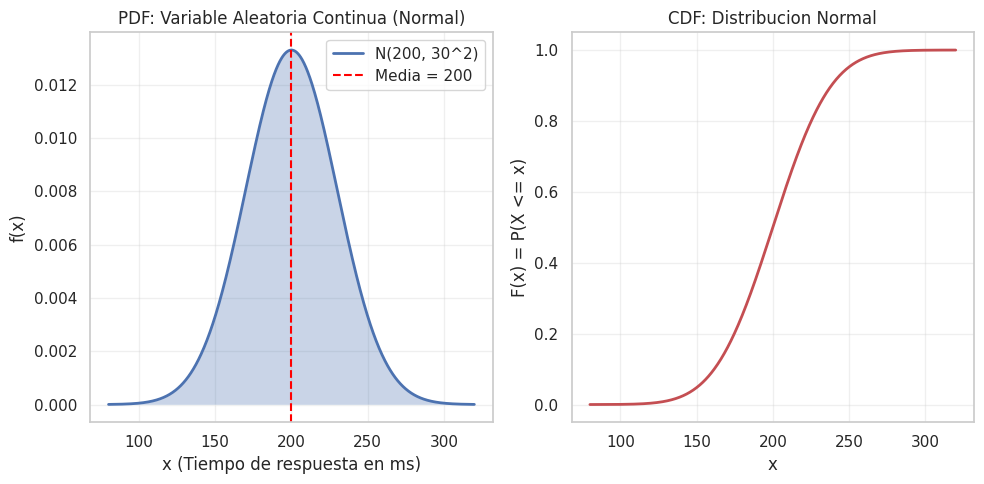

In [8]:
# ==========================================
# 3. Caso Continuo (Servidor Web)
# ==========================================
print("--- Resultados del Caso Continuo (Servidor) ---")
#Caso: X = tiempo de respuesta de un servidor (ms), distribuido normalmente con mu = 200 y sigma = 30.

# Parametros de la distribucion normal
mu = 200 # media
sigma = 30 # desviacion estandar

# Crear la distribucion
dist_normal = stats.norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Cálculo de Probabilidades**

In [9]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")
# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")
# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")
# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")

P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


### **Celda 4: Análisis Comparativo**

   ANÁLISIS COMPARATIVO DE VARIABLES
MUNDO DISCRETO (Dado):
Representamos la probabilidad con líneas verticales (stem).
Cada evento tiene una probabilidad exacta de 0.1667.
------------------------------------------
MUNDO CONTINUO (Servidor Web):
La probabilidad es el área sombreada bajo la curva.
El 95% de los tiempos de respuesta son menores a 249.3 ms.



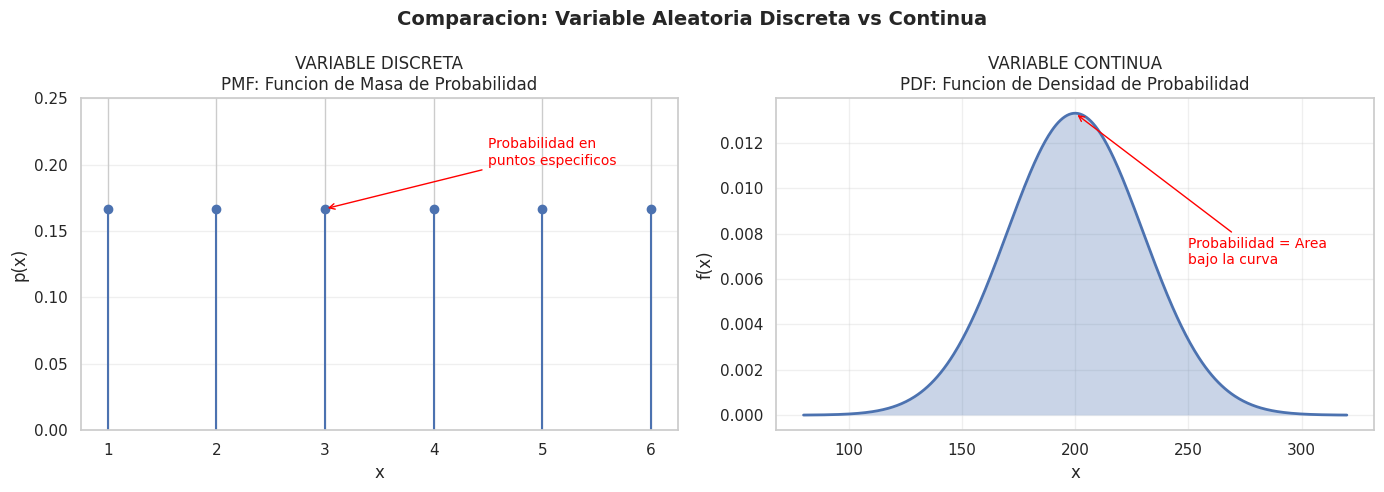

In [7]:
# --- Definición de variables (necesarias para el análisis) ---
resultados = np.array([1, 2, 3, 4, 5, 6])
pmf_valores = np.full(6, 1/6)
dist_normal = stats.norm(loc=200, scale=30)
percentil_95 = dist_normal.ppf(0.95)

# --- Bloque de texto con el análisis (Antes de la imagen) ---
print("==========================================")
print("   ANÁLISIS COMPARATIVO DE VARIABLES")
print("==========================================")
print(f"MUNDO DISCRETO (Dado):")
print(f"Representamos la probabilidad con líneas verticales (stem).")
print(f"Cada evento tiene una probabilidad exacta de {1/6:.4f}.")
print("-" * 42)
print(f"MUNDO CONTINUO (Servidor Web):")
print(f"La probabilidad es el área sombreada bajo la curva.")
print(f"El 95% de los tiempos de respuesta son menores a {percentil_95:.1f} ms.")
print("==========================================\n")

# ==========================================
# 4. Análisis Comparativo (Visualización)
# ==========================================
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(dado, pmf_valores, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(dado)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)
# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6),
xytext=(4.5, 0.2),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')

# Variable Continua (Normal)
x_continuo = np.linspace(mu - 4*sigma, mu + 4*sigma, 500) # Ensure x_continuo is defined for plotting
y_continuo = dist_normal.pdf(x_continuo) # Ensure y_continuo is defined for plotting
axes[1].plot(x_continuo, y_continuo, 'b-', linewidth=2)
axes[1].fill_between(x_continuo, y_continuo, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)
# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(mu, dist_normal.pdf(mu)), xytext=(mu + 50, dist_normal.pdf(mu)/2),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **Celda 5: Análisis Consolidado de Distribuciones de Probabilidad**

A continuación, se presenta un análisis consolidado de diferentes escenarios, clasificando su tipo de variable, distribución esperada y justificación en una única tabla.

| Escenario | Tipo | Distribución Esperada | Justificación |
| :-------- | :--- | :-------------------- | :------------ |
| Número de estudiantes que ingresan a la biblioteca por hora | Discreta | Poisson | Se trata de contar llegadas independientes en un intervalo de tiempo fijo, lo cual es característico de la distribución de Poisson. |
| Tiempo de espera en la fila de la cafetería | Continua | Exponencial | El tiempo de espera en un sistema de colas con tasa de servicio constante se modela con la distribución exponencial, ya que los tiempos entre atenciones son independientes entre sí. |
| Número de equipos conectados a la red Wi-Fi del laboratorio | Discreta | Binomial (n=30, p≈0.8) | Cada puesto del laboratorio puede estar conectado (éxito) o vacío (fracaso) con una probabilidad fija p. Con n puestos fijos e independientes, el total de equipos conectados sigue una distribución binomial. |
| Número de autos que ingresan al estacionamiento por día | Discreta | Poisson | Es adecuado para modelar eventos raros que ocurren en un intervalo de tiempo o espacio fijo, como la llegada de autos. |
| Temperatura ambiente en el aula | Continua | Normal | Las mediciones de temperatura tienden a fluctuar de forma simétrica alrededor de una media, comportamiento típico de la distribución normal, donde múltiples factores pequeños se combinan. |

**Tabla de Registro**

In [6]:
# Plantilla para registro de variables
variables_unl = [
    {
        'nombre': 'Número de estudiantes que ingresan a la biblioteca por hora',
        'ubicacion': 'Biblioteca',
        'tipo': 'Discreta',
        'valores_posibles': '0, 1, 2, 3, ... (sin límite teórico)',
        'distribucion_esperada': 'Poisson'
    },
    {
        'nombre': 'Tiempo de espera en la fila de la cafetería',
        'ubicacion': 'Cafetería',
        'tipo': 'Continua',
        'valores_posibles': 'X ≥ 0 (ej: 0 a 15 minutos)',
        'distribucion_esperada': 'Exponencial'
    },
    {
        'nombre': 'Número de equipos conectados a la red Wi-Fi del    laboratorio',
        'ubicacion': 'Laboratorios',
        'tipo': 'Discreta',
        'valores_posibles': '0 ≤ X ≤ 30',
        'distribucion_esperada': 'Binomial (n=30, p≈0.8)'
    },
    {
        'nombre': 'Número de autos que ingresan al estacionamiento por día',
        'ubicacion': 'Estacionamiento',
        'tipo': 'Discreta',
        'valores_posibles': '0, 1, 2, 3, ... (sin límite teórico)',
        'distribucion_esperada': 'Poisson'
    },
    {
        'nombre': 'Temperatura ambiente en el aula',
        'ubicacion': 'Aulas de clase',
        'tipo': 'Continua',
        'valores_posibles': '(-∞, ∞) (ej: 18°C a 30°C)',
        'distribucion_esperada': 'Normal'
    }
]

# Mostrar en formato de tabla
import pandas as pd
df = pd.DataFrame(variables_unl)
print(df.to_string(index=False))

                                                        nombre       ubicacion     tipo                     valores_posibles  distribucion_esperada
   Número de estudiantes que ingresan a la biblioteca por hora      Biblioteca Discreta 0, 1, 2, 3, ... (sin límite teórico)                Poisson
                   Tiempo de espera en la fila de la cafetería       Cafetería Continua           X ≥ 0 (ej: 0 a 15 minutos)            Exponencial
Número de equipos conectados a la red Wi-Fi del    laboratorio    Laboratorios Discreta                           0 ≤ X ≤ 30 Binomial (n=30, p≈0.8)
       Número de autos que ingresan al estacionamiento por día Estacionamiento Discreta 0, 1, 2, 3, ... (sin límite teórico)                Poisson
                               Temperatura ambiente en el aula  Aulas de clase Continua            (-∞, ∞) (ej: 18°C a 30°C)                 Normal


# **Trabajo Autónimo** - *Emily Salas Paz*

### **Variable Aleatoria Discreta** (D*istribución Binomial*)

📌 Planteamiento del caso

Se modela el número de estudiantes que aprueban un examen en un grupo de 10, donde cada estudiante tiene una probabilidad de aprobar de p=0.7.

X∼Binomial(n=10,p=0.7)

***Implementación para la Distribución Binomial***

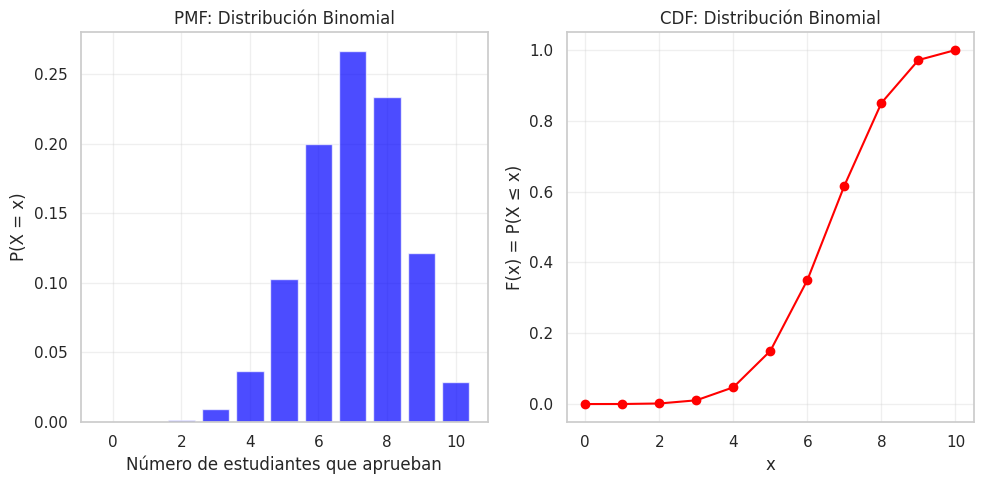


Cálculo de Probabilidades:

P(X = 7) = 0.2668
Interpretación: Hay una probabilidad del 26.68% de que exactamente 7 de los 10 estudiantes aprueben el examen.

P(X ≤ 5) = 0.1503
Interpretación: Hay una probabilidad del 15.03% de que 5 o menos estudiantes aprueben el examen.

P(X ≥ 8) = 0.3828
Interpretación: Hay una probabilidad del 38.28% de que 8 o más estudiantes aprueben el examen.


In [24]:
# =================================================
# 1. Definir la distribución y graficar PMF y CDF
# =================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros
n = 10   # número de estudiantes
p = 0.7  # probabilidad de aprobar

# Crear la distribución
dist_binom = binom(n, p)

# Valores posibles
x_vals = np.arange(0, n+1)

# PMF y CDF
pmf_binom = dist_binom.pmf(x_vals)
cdf_binom = dist_binom.cdf(x_vals)

# Visualización
plt.figure(figsize=(10, 5))

# PMF
plt.subplot(1, 2, 1)
plt.bar(x_vals, pmf_binom, color='blue', alpha=0.7)
plt.xlabel('Número de estudiantes que aprueban')
plt.ylabel('P(X = x)')
plt.title('PMF: Distribución Binomial')
plt.grid(alpha=0.3)

# CDF
plt.subplot(1, 2, 2)
plt.plot(x_vals, cdf_binom, marker='o', color='red')
plt.xlabel('x')
plt.ylabel('F(x) = P(X ≤ x)')
plt.title('CDF: Distribución Binomial')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==================================================
# 2. Cálculo de probabilidades
# ==================================================

print("\nCálculo de Probabilidades:")

# a) Probabilidad de que exactamente 7 aprueben
p1 = dist_binom.pmf(7)
print(f'\nP(X = 7) = {p1:.4f}')
print(f"Interpretación: Hay una probabilidad del {p1*100:.2f}% de que exactamente 7 de los 10 estudiantes aprueben el examen.")

# b) Probabilidad de que como máximo 5 aprueben
p2 = dist_binom.cdf(5)
print(f'\nP(X ≤ 5) = {p2:.4f}')
print(f"Interpretación: Hay una probabilidad del {p2*100:.2f}% de que 5 o menos estudiantes aprueben el examen.")

# c) Probabilidad de que al menos 8 aprueben
p3 = 1 - dist_binom.cdf(7)
print(f'\nP(X ≥ 8) = {p3:.4f}')
print(f"Interpretación: Hay una probabilidad del {p3*100:.2f}% de que 8 o más estudiantes aprueben el examen.")

### *Interpretación de Resultados*


---

En este modelo, la variable aleatoria X representa el número de estudiantes que aprueban un examen en un grupo de 10, donde cada estudiante tiene una probabilidad de aprobación del 70%.

---

**1. P(X=7)**

Esta probabilidad indica la posibilidad de que exactamente 7 estudiantes aprueben el examen.

*Interpretación:*

*   Este resultado es cercano al valor esperado (promedio), ya que en promedio se espera que aprueben n⋅p=10⋅0.7=7 estudiantes.
Por lo tanto, es un escenario muy probable y representativo del comportamiento típico del grupo.

---

**2. P(X≤5)**

Esta probabilidad representa la posibilidad de que 5 o menos estudiantes aprueben.

*Interpretación:*

*   Este es un resultado por debajo de lo esperado, lo que podría indicar que el
rendimiento del grupo fue bajo.
Si esta probabilidad es pequeña, significa que no es común que pocos estudiantes aprueben, por lo que, en condiciones normales, el grupo tiende a tener mejores resultados.

---

**3. P(X≥8)**

Esta probabilidad indica la posibilidad de que 8 o más estudiantes aprueben el examen.

*Interpretación:*

*   Este resultado refleja un rendimiento alto del grupo.
Si la probabilidad es moderada o alta, significa que es bastante probable que la mayoría de los estudiantes aprueben, lo cual puede indicar que el examen fue accesible o que el grupo está bien preparado.

---

### *Conclusión*

En conjunto, los resultados muestran que el comportamiento más probable es que alrededor de 7 estudiantes aprueben, mientras que escenarios extremos (muy pocos o muchos aprobados) tienen menor probabilidad.
Esto confirma que la distribución binomial permite analizar de forma clara el rendimiento esperado y las variaciones posibles dentro de un grupo.



---

# **Preguntas de Control**

## **Pregunta 1**

### **¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

Una variable aleatoria discreta toma valores en un conjunto finito o infinito numerable (como los enteros no negativos), mientras que una variable aleatoria continua puede tomar cualquier valor en un intervalo de los números reales. La distinción está en que la discreta se habla de la probabilidad en un punto específico mediante la PMF, mientras que en la continua esa probabilidad es siempre cero y la probabilidad solo tiene sentido en intervalos mediante la PDF y la integral.

-----

## **Pregunta 2**

### **¿Por qué en una variable continua P(X = x) = 0 para cualquier valor específico x?**

Esto ocurre porque en una variable continua existen infinitos valores posibles dentro de un intervalo. Como la probabilidad se distribuye en todo ese rango, no se concentra en un solo punto. Por ello, la probabilidad de que la variable tome exactamente un valor específico es cero, y en su lugar se calculan probabilidades en intervalos.

----

## **Pregunta 3**

### **Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?**

La CDF representa la probabilidad acumulada hasta un valor determinado. En una variable discreta, la CDF se obtiene sumando las probabilidades de la PMF hasta ese valor. En una variable continua, se obtiene integrando la PDF. Por otro lado, para obtener la PMF a partir de la CDF en el caso discreto se usan diferencias entre valores, mientras que en el caso continuo la PDF se obtiene derivando la CDF.

-----

## **Pregunta 4**

### **Una variable aleatoria X representa el número de estudiantes que llegan tarde a clase. ¿Es X discreta o continua? Justifique.**

Es una variable discreta, ya que representa una cantidad que se puede contar y solo puede tomar valores enteros (0, 1, 2, 3, etc.). No es posible tener valores fraccionarios de estudiantes.

-----

## **Pregunta 5**

### **Calcule P(X = 5) para una variable continua con PDF f(x) = 2x en [0,1]. Explique su respuesta.**

P(X = 5) = 0, por dos razones:
•	Razón 1 (teórica): En cualquier variable aleatoria continua, la probabilidad puntual es siempre cero: P(X = c) = ∫_c^c f(x)dx = 0 para cualquier constante c.
•	Razón 2 (dominio): La PDF f(x) = 2x está definida únicamente en el intervalo [0, 1]. El valor x = 5 está fuera del dominio de esta distribución. Por lo tanto, f(5) = 0 y consecuentemente P(X = 5) = 0.
Verificación: ∫₀¹ 2x dx = [x²]₀¹ = 1  ✓  (la función sí es una PDF válida en [0,1])

-----

## **Pregunta 6**

### **Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**

Tabla de la CDF:

| x | p(x) | F(x) = P(X ≤ x) |
| :---: | :---: | :---: |
| 1 | 0.3 | 0.3 |
| 2 | 0.5 | 0.8 |
| 3 | 0.2 | 1.0 |

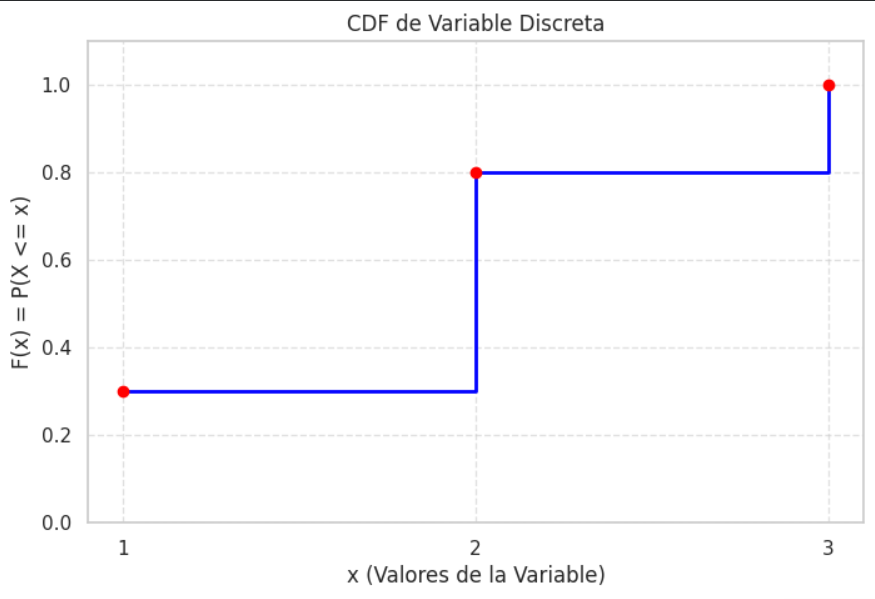

La CDF es una función escalera (step function) que:

*	F(x) = 0 para x < 1
*	F(x) = 0.3 para 1 ≤ x < 2  (salto de 0.3 en x = 1)
*	F(x) = 0.8 para 2 ≤ x < 3  (salto de 0.5 en x = 2)
*	F(x) = 1.0 para x ≥ 3      (salto de 0.2 en x = 3)

Descripción del gráfico: es una escalera ascendente con tres escalones de altura 0.3, 0.5 y 0.2 en los puntos x = 1, 2 y 3 respectivamente. En cada salto, el punto está cerrado (incluido) en el valor superior.

------

## **Pregunta 7**

### **Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique por qué es continua.**

Un ejemplo es el tiempo de ejecución de un algoritmo. Es una variable continua porque puede tomar cualquier valor dentro de un intervalo, incluyendo valores decimales como 1.2 o 1.35 segundos. No se limita a valores enteros, por lo que puede variar de forma infinita dentro de un rango.
